# scRNA Sequencing using scanpy
## Preprocessing, Normalization & Log-transformation, 
## Doublet Detection, Feature Selection
## Scaling, Dimentionality Reduction
## Batch Correction with Harmony
## UMAP & Clustering

In [1]:
import warnings
# Suppress all warnings
warnings.filterwarnings('ignore')

In [2]:
# install scanpy
#%pip install scanpy 


In [3]:
#%pip install scvi-tools

In [4]:
#import sys
#!{sys.executable} -m pip install python-igraph leidenalg

In [5]:
#%pip install harmonypy


In [6]:
import scanpy as sc
import scvi
import harmonypy
import igraph
import leidenalg

print(igraph.__version__)
print("Scanpy:", sc.__version__)
print("scvi-tools:", scvi.__version__)
print(harmonypy.__version__)


0.11.9
Scanpy: 1.11.4
scvi-tools: 1.4.0
0.0.10


## Lung 10x Genomics Data
The datasets used here were collected from 10X Genomics publicly available datasets. 

In [7]:
import anndata as ad

files = [
    "20k_NSCLC_DTC_3p_nextgem_donor_1_count_sample_feature_bc_matrix.h5",
    "20k_NSCLC_DTC_3p_nextgem_donor_5_count_sample_feature_bc_matrix.h5",
    "20k_NSCLC_DTC_3p_nextgem_donor_6_count_sample_feature_bc_matrix.h5",
]

adatas = []
for i, f in enumerate(files, 1):
    Sample_adata = sc.read_10x_h5(f)
    
    # Ensure unique gene names
    Sample_adata.var_names_make_unique()
    
    # Prefix cell barcodes with sample ID to keep them unique globally
    Sample_adata.obs_names = [f"Sample{i}_{bc}" for bc in Sample_adata.obs_names]
    
    # Add sample info
    Sample_adata.obs["Sample"] = f"Sample_{i}"
    
    adatas.append(Sample_adata)

# Concatenate all samples into one AnnData object
adata_all = ad.concat(adatas, join="outer", label="Sample_id", fill_value=0)



In [8]:
print("Number of cells (obs):", adata_all.n_obs)
print("Number of genes (var):", adata_all.n_vars)

# Count cells per sample using the 'Sample' column in obs
cell_counts = adata_all.obs['Sample'].value_counts()
print(cell_counts)


Number of cells (obs): 6879
Number of genes (var): 36601
Sample
Sample_3    2921
Sample_2    2378
Sample_1    1580
Name: count, dtype: int64


In [9]:
import numpy as np
import scanpy as sc

# Helper function to safely get a 1D array
def to_1d(x):
    if hasattr(x, "A1"):  # sparse matrix
        return x.A1
    return np.array(x).ravel()

# Total counts per cell
adata_all.obs['total_counts'] = to_1d(adata_all.X.sum(axis=1))

# Number of genes detected per cell
adata_all.obs['n_genes_by_counts'] = to_1d((adata_all.X > 0).sum(axis=1))

# Mitochondrial gene percentage
mt_genes = adata_all.var_names.str.upper().str.startswith('MT-')
adata_all.obs['pct_counts_mt'] = to_1d(adata_all.X[:, mt_genes].sum(axis=1)) / adata_all.obs['total_counts'] * 100

# Ribosomal gene percentage
ribo_genes = adata_all.var_names.str.upper().str.startswith(('RPS', 'RPL'))
adata_all.obs['pct_counts_ribo'] = to_1d(adata_all.X[:, ribo_genes].sum(axis=1)) / adata_all.obs['total_counts'] * 100

# Check
adata_all.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'Sample']].head()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo,Sample
Sample1_AAACCCAGTCTTCGAA-1,5266,29888.0,2.606397,29.025026,Sample_1
Sample1_AAACCCATCACATACG-1,5607,20348.0,0.481620,15.505210,Sample_1
Sample1_AAACGAAAGCCTAACT-1,4147,23584.0,3.180122,12.648405,Sample_1
Sample1_AAACGCTAGACAGTCG-1,1045,3410.0,3.431085,24.017595,Sample_1
Sample1_AAACGCTCAGCAAGAC-1,3470,12665.0,1.097513,34.433479,Sample_1


- **`n_genes_by_counts`** provides a measure of how many genes are actively expressed in a particular cell.
- **`total_counts`** refers to the total number of RNA counts (or read counts) for each cell, representing the overall sequencing depth.
- **`pct_counts_mt`** refers to the percentage of counts in each cell that come from mitochondrial genes.

In [10]:
#Inspect obs (cells metadata)
adata_all.obs.head()

,Sample,Sample_id,total_counts,n_genes_by_counts,pct_counts_mt,pct_counts_ribo
Sample1_AAACCCAGTCTTCGAA-1,Sample_1,0,29888.0,5266,2.606397,29.025026
Sample1_AAACCCATCACATACG-1,Sample_1,0,20348.0,5607,0.481620,15.505210
Sample1_AAACGAAAGCCTAACT-1,Sample_1,0,23584.0,4147,3.180122,12.648405
Sample1_AAACGCTAGACAGTCG-1,Sample_1,0,3410.0,1045,3.431085,24.017595
Sample1_AAACGCTCAGCAAGAC-1,Sample_1,0,12665.0,3470,1.097513,34.433479


# Preprocessing
## Quality Control
However, since some unusual QC metrics may reflect genuine biological variation, it is recommended to start with very lenient filtering and refine it later.  

For now, we only remove cells with fewer than **100 genes detected** and genes that appear in fewer than **3 cells**.

In [11]:
# Calculate QC metrics
adata_all.var["mt"] = adata_all.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata_all, qc_vars=["mt"], inplace=True)

# Filter cells and genes
sc.pp.filter_cells(adata_all, min_genes=200)
sc.pp.filter_genes(adata_all, min_cells=3)

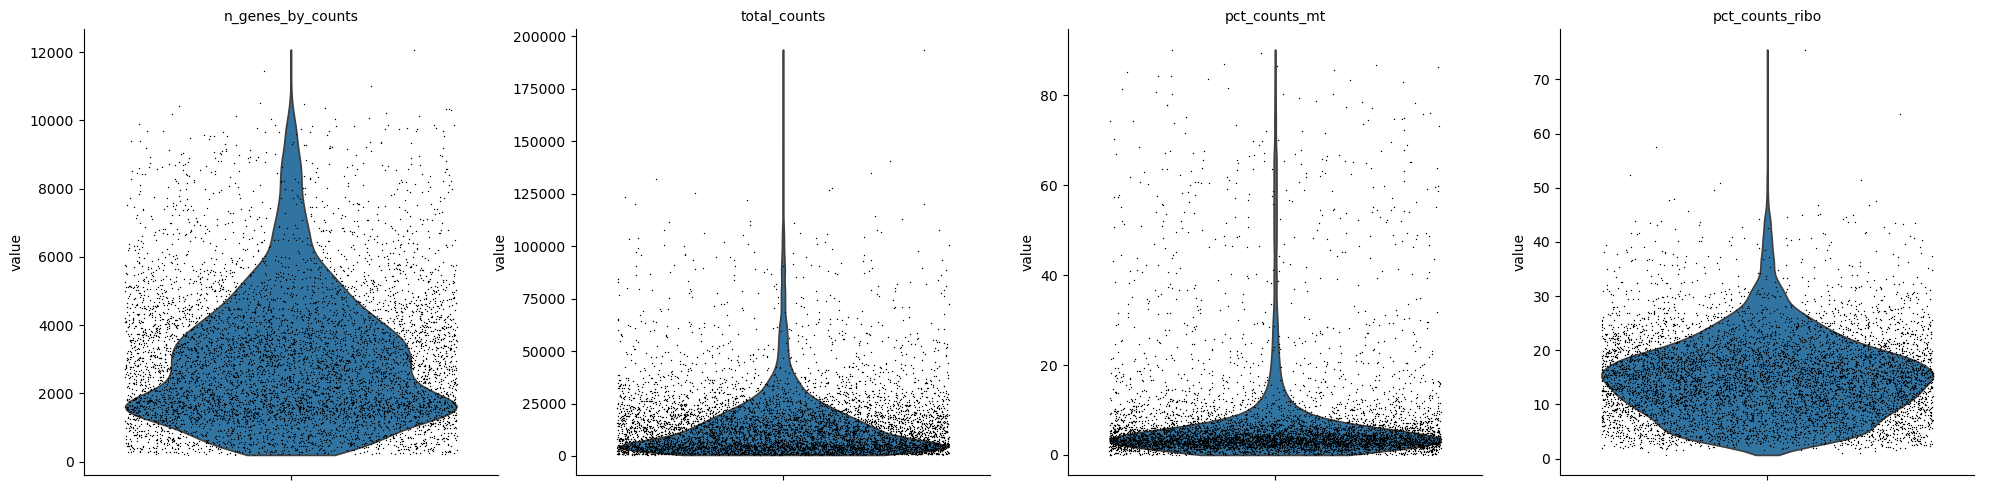

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

sc.pl.violin(
    adata_all, 
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'], 
    jitter=0.4, 
    multi_panel=True
)

plt.suptitle('QC metrics across donors', fontsize=16)
plt.show()

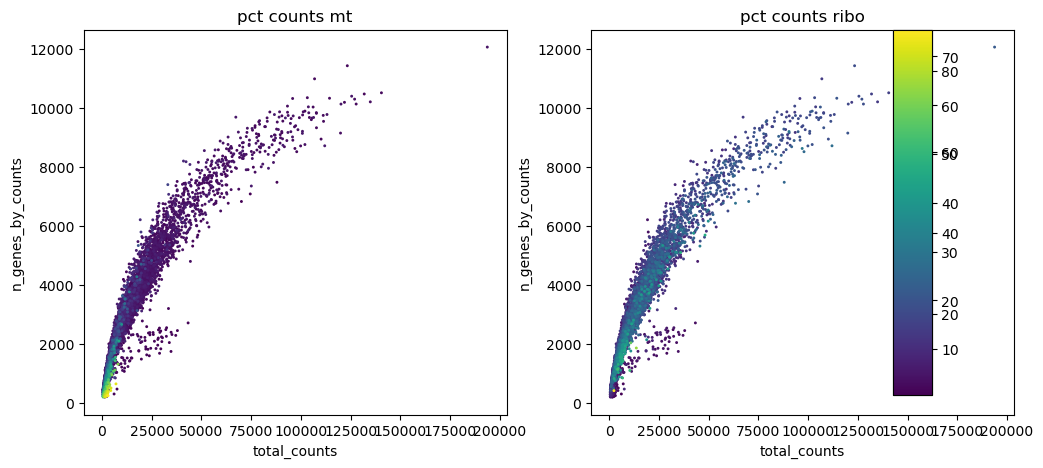

In [13]:
# Create two subplot axes side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# First scatter plot: mitochondrial percentage
sc.pl.scatter(
    adata_all,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
    ax=axs[0],
    show=False
)

# Second scatter plot: ribosomal percentage
sc.pl.scatter(
    adata_all,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_ribo",
    ax=axs[1],
    show=True  # Show the combined figure after both plots are done
)

In [14]:
# Check shape
print(adata_all.shape)
print("Number of cells (obs):", adata_all.n_obs)
print("Number of genes (var):", adata_all.n_vars)

(6859, 26674)
Number of cells (obs): 6859
Number of genes (var): 26674


## Normalization and log Transformation

### What `target_sum=1e4` does

`normalize_total` scales each cell’s total counts (UMIs) so that the sum of counts for each cell equals `target_sum`, in this case **10,000**.

Essentially, it **puts all cells on the same scale**, removing differences due to sequencing depth.

After this, every cell is comparable, even if some were sequenced deeper than others.

#### After normalization

All cells have the **same total counts**, so differences now reflect **biological variation**, not sequencing depth.

In [15]:
sc.pp.normalize_total(adata_all, target_sum=1e4)
sc.pp.log1p(adata_all)


In [16]:
# Checking for normalization
import numpy as np

X = adata_all.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

print(f"Min: {X.min():.2f}, Max: {X.max():.2f}, Mean: {X.mean():.2f}")


Min: 0.00, Max: 8.91, Mean: 0.10


## Doublet Detection

In [17]:
from scvi.external import SOLO

# Set up AnnData for scVI
scvi.model.SCVI.setup_anndata(adata_all)

# Train scVI
vae = scvi.model.SCVI(adata_all)
vae.train()  # Use GPU

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


#### Run Solo for Doublet Detection

In [18]:
# Now initialize SOLO using the trained VAE model:
solo = scvi.external.SOLO.from_scvi_model(vae)

# Train SOLO (adjust number of epochs if needed)
solo.train(max_epochs=150)

# Predict doublets
predictions = solo.predict()


INFO     Creating doublets, preparing SOLO model.                                                                  


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/150 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=150` reached.


In [19]:
# Create prediction label: if singlet score > 0.5, classify as singlet, else doublet
predictions['prediction'] = predictions['singlet'].apply(lambda x: 'singlet' if x > 0.5 else 'doublet')

# Add to adata.obs
adata_all.obs["solo_prediction"] = predictions['prediction'].values
adata_all.obs["solo_doublet_score"] = predictions['doublet'].values

# View results
print(adata_all.obs["solo_prediction"].value_counts())
print(adata_all.obs[["solo_prediction", "solo_doublet_score"]].head())


solo_prediction
singlet    6854
doublet       5
Name: count, dtype: int64
                           solo_prediction  solo_doublet_score
Sample1_AAACCCAGTCTTCGAA-1         singlet            0.000407
Sample1_AAACCCATCACATACG-1         singlet            0.028810
Sample1_AAACGAAAGCCTAACT-1         singlet            0.007316
Sample1_AAACGCTAGACAGTCG-1         singlet            0.000107
Sample1_AAACGCTCAGCAAGAC-1         singlet            0.000750


### Filter out doublets

In [20]:
adata_filtered = adata_all[adata_all.obs["solo_prediction"] == "singlet"].copy()
print(f"Cells after doublet removal: {adata_filtered.n_obs}")


Cells after doublet removal: 6854


In [21]:
adata_filtered

AnnData object with n_obs × n_vars = 6854 × 26674
    obs: 'Sample', 'Sample_id', 'total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'n_genes', '_scvi_batch', '_scvi_labels', 'solo_prediction', 'solo_doublet_score'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', '_scvi_uuid', '_scvi_manager_uuid'

## Feature Selection

In [22]:
sc.pp.highly_variable_genes(
    adata_filtered, 
    flavor="seurat", 
    n_top_genes=2000, 
    batch_key="Sample"
)

adata = adata_filtered[:, adata_filtered.var["highly_variable"]].copy()


In [23]:
# Save AnnData for further analysis
adata_filtered.write("adata_filtered.h5ad")

In [24]:
adata_filtered.raw = adata_filtered.copy()

## Scaling and PCA

In [25]:
## Scale the data (z-score per gene)
sc.pp.scale(adata_filtered, max_value=10)

## Dimnetionality Reduction
sc.tl.pca(adata_filtered, svd_solver="arpack")


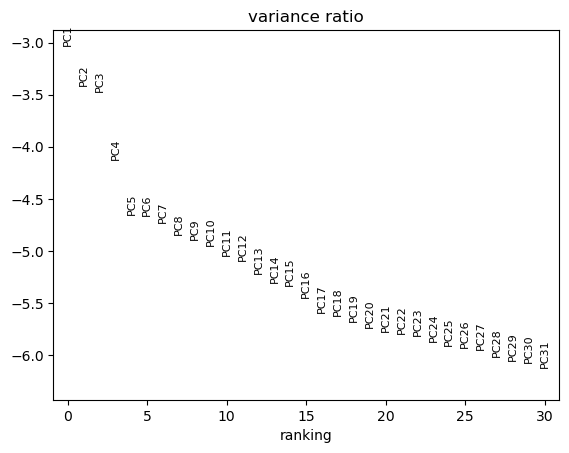

In [26]:
sc.pl.pca_variance_ratio(adata_filtered, log=True)  # elbow plot

## Harmony Integration

In [27]:
import scanpy.external as sce
sce.pp.harmony_integrate(adata_filtered, key="Sample")


2025-09-16 10:23:13,410 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-16 10:23:32,613 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-16 10:23:32,639 - harmonypy - INFO - Iteration 1 of 10
2025-09-16 10:23:33,621 - harmonypy - INFO - Iteration 2 of 10
2025-09-16 10:23:34,617 - harmonypy - INFO - Iteration 3 of 10
2025-09-16 10:23:35,620 - harmonypy - INFO - Iteration 4 of 10
2025-09-16 10:23:36,527 - harmonypy - INFO - Iteration 5 of 10
2025-09-16 10:23:37,236 - harmonypy - INFO - Iteration 6 of 10
2025-09-16 10:23:38,307 - harmonypy - INFO - Iteration 7 of 10
2025-09-16 10:23:39,043 - harmonypy - INFO - Iteration 8 of 10
2025-09-16 10:23:39,894 - harmonypy - INFO - Iteration 9 of 10
2025-09-16 10:23:40,337 - harmonypy - INFO - Iteration 10 of 10
2025-09-16 10:23:40,729 - harmonypy - INFO - Stopped before convergence


## Neighbors, UMAP, Clustering

In [28]:
## Build neighborhood graph
## For downstream clustering and UMAP.
sc.pp.neighbors(adata_filtered, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_filtered)
sc.tl.leiden(adata_filtered, resolution=0.5)


## Visualization

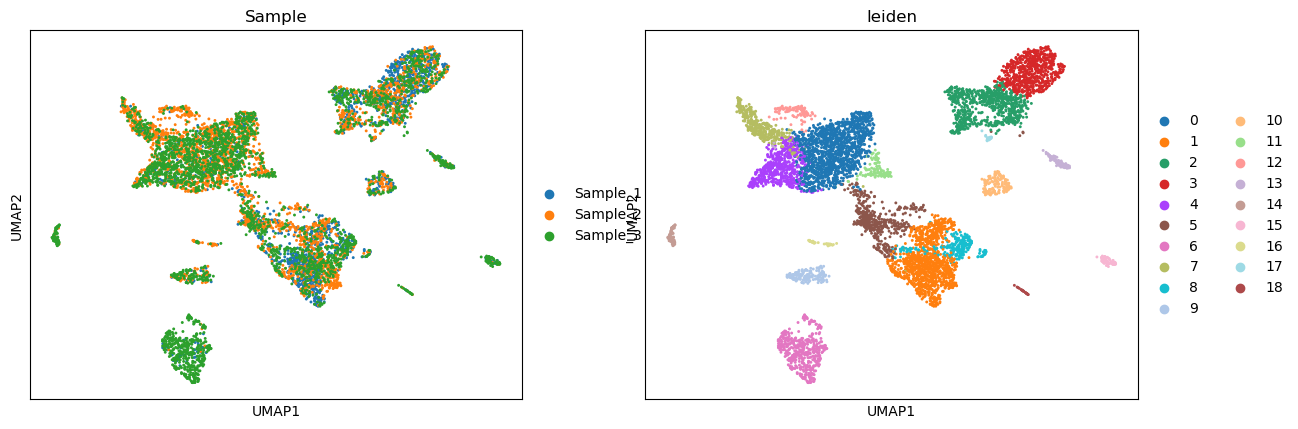

In [29]:
sc.pl.umap(adata_filtered, color=["Sample", "leiden"])
